# 函数拟合

In [1]:
import numpy as np

In [2]:
# 要拟合的函数
def complex_func1(x):
    return 1 / (1 + np.exp(- (np.sin(5*x) + 0.5*np.cos(3*x))))

def real(x):
    return complex_func1(x)

In [3]:
D0 = 1 # 输入层 1 个x样本
D1 = 20
D2 = 20
D3 = D0 # 输出层

W1 = np.random.randn(D1, D0)
W2 = np.random.randn(D2, D1)
W3 = np.random.randn(D3, D2)
B1 = np.random.randn(D1, 1)
B2 = np.random.randn(D2, 1)
B3 = np.random.randn(D3, 1)

def Activate(X):
    return np.tanh(X)
def pActivate(X):
    return 1 - np.tanh(X)**2

eta = 1e-3

def evaluation(X0):
    AX1 = W1 @ X0 + B1
    X1 = Activate(AX1)
    AX2 = W2 @ X1 + B2
    X2 = Activate(AX2)
    AX3 = W3 @ X2 + B3
    X3 = AX3 # 因为是回归问题，所以输出层不加激活函数
    Y = X3
    return Y

def train(nIters):
    global W1,W2,W3,B1,B2,B3
    iters = []
    losses = []
    for it in range(nIters):
        X0 = np.random.randn(D0, 1) # 输入一般在[0,1] 或 [-1,1] 之间
        AX1 = W1 @ X0 + B1
        X1 = Activate(AX1)
        AX2 = W2 @ X1 + B2
        X2 = Activate(AX2)
        AX3 = W3 @ X2 + B3
        X3 = AX3 # 因为是回归问题，所以输出层不加激活函数
        Y = X3

        R = real(X0)
        E = Y - R
        L = 0.5 * E.T @ E

        d_L_d_X3 = E
        delta3 = d_L_d_X3
        d_L_d_W3 = delta3 @ X2.T
        d_L_d_B3 = delta3

        delta2 = W3.T @ delta3 * pActivate(AX2)
        d_L_d_W2 = delta2 @ X1.T
        d_L_d_B2 = delta2

        delta1 = W2.T @ delta2 * pActivate(AX1)
        d_L_d_W1 = delta1 @ X0.T
        d_L_d_B1 = delta1

        W3 = W3 - eta * d_L_d_W3
        B3 = B3 - eta * d_L_d_B3
        W2 = W2 - eta * d_L_d_W2
        B2 = B2 - eta * d_L_d_B2
        W1 = W1 - eta * d_L_d_W1
        B1 = B1 - eta * d_L_d_B1

        iters.append(it)
        losses.append(np.sum(L))

        print(f"\rIter: {it}, Loss: {np.sum(L)}", end="")
    return iters, losses

iters, losses = train(10000)

Iter: 9999, Loss: 0.00232073048891255464

# 损失函数曲线

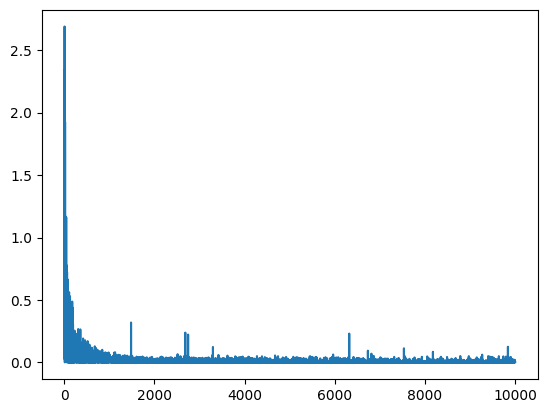

In [4]:
import matplotlib.pyplot as plt
plt.plot(iters, losses)

# 拟合曲线对比

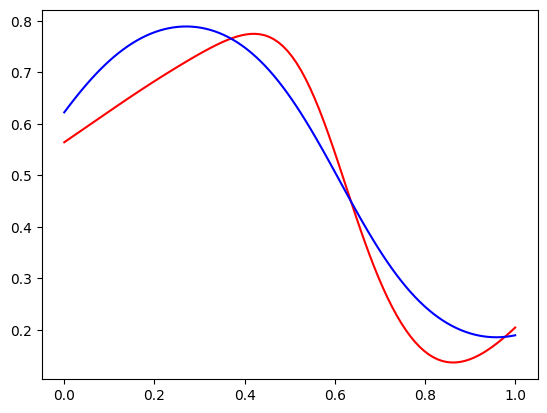

In [5]:
xs = np.linspace(0,1,100)
ys = []
rs = []
for i in range(len(xs)):
    x = xs[i]
    y = evaluation(np.array([x]).reshape(1,1))[0][0]
    r = real(x)
    ys.append(y)
    rs.append(r)

plt.plot(xs,ys, color='r')
plt.plot(xs,rs, color='b')